# Telco Customer Churn MLOps Checks

This notebook validates the Telco churn dataset, cleans hidden missing values, runs a focused EDA, and builds a reproducible scikit-learn preprocessing pipeline for production-safe modeling.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

DATA_PATH = Path.cwd() / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

## Section 1: Data Loading & MLOps Validation Checks

We validate schema, uniqueness, and class balance before any preprocessing or modeling work.

Dataset shape: (7043, 21)


,count,percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


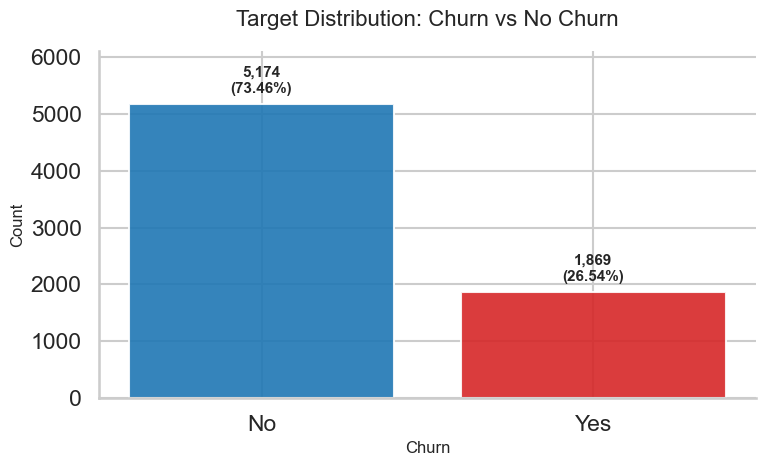

Exact churn percentages:
       percentage
Churn            
No      73.463013
Yes     26.536987


In [2]:
df_raw = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df_raw.shape}')
assert df_raw.shape[1] == 21, f'Expected 21 columns, found {df_raw.shape[1]}'
assert df_raw['customerID'].is_unique, 'customerID is not unique'

churn_counts = df_raw['Churn'].value_counts().reindex(['No', 'Yes'])
churn_percent = df_raw['Churn'].value_counts(normalize=True).reindex(['No', 'Yes']) * 100

validation_summary = pd.DataFrame({
    'count': churn_counts,
    'percentage': churn_percent,
})
validation_summary.index.name = 'Churn'
display(validation_summary)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(churn_counts.index, churn_counts.values, color=['#1f77b4', '#d62728'], alpha=0.9)
ax.set_title('Target Distribution: Churn vs No Churn', pad=18)
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
ax.set_ylim(0, churn_counts.max() * 1.18)
for bar, count, pct in zip(bars, churn_counts.values, churn_percent.values):
    ax.annotate(
        f'{count:,}\n({pct:.2f}%)',
        xy=(bar.get_x() + bar.get_width() / 2, count),
        xytext=(0, 6),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
    )
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Exact churn percentages:')
print(churn_percent.to_frame(name='percentage'))

## Section 2: Data Cleaning & Handling Missing Values

We convert hidden blanks in `TotalCharges` into numeric missing values, impute them with zero, and drop `customerID` from the modeling frame.

Rows converted to NaN in TotalCharges: 11


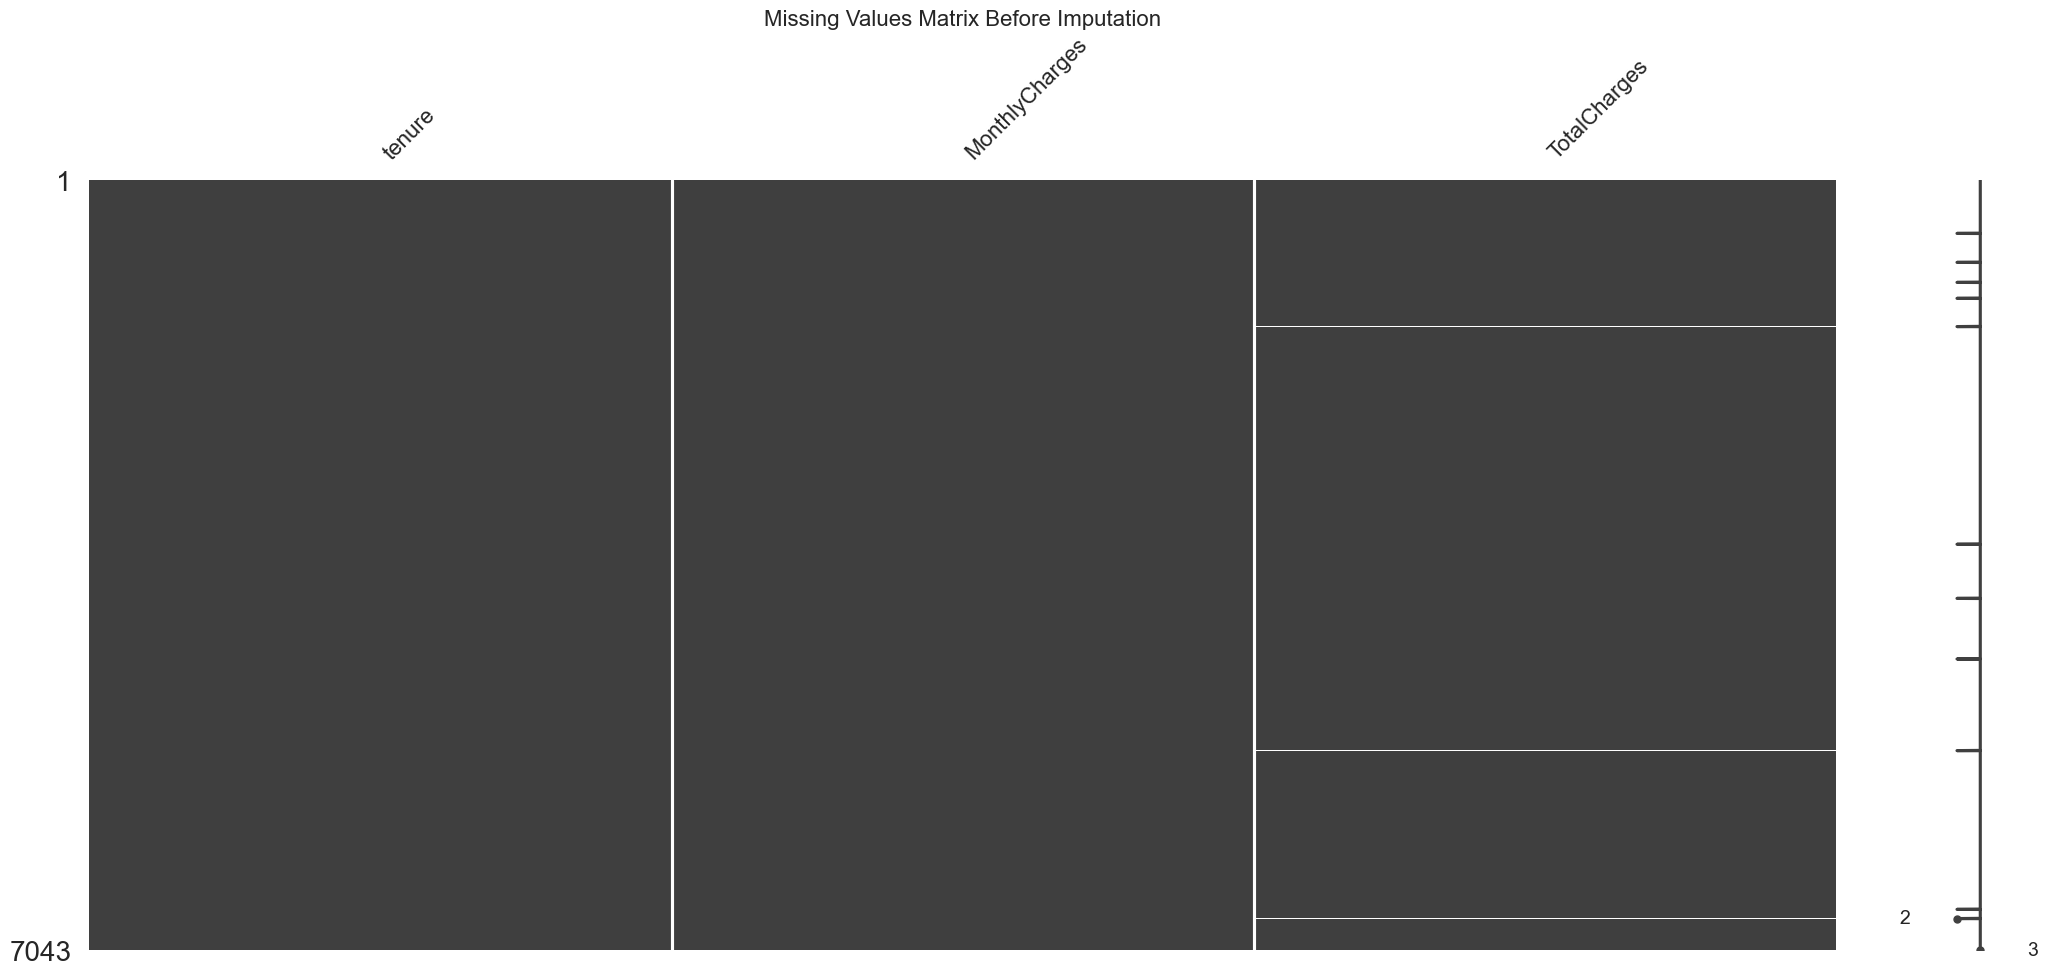

Data types after cleaning:


,dtype
tenure,int64
MonthlyCharges,float64
TotalCharges,float64


Remaining missing values:


,missing_count
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_clean = df_raw.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

missing_totalcharges = int(df_clean['TotalCharges'].isna().sum())
print(f'Rows converted to NaN in TotalCharges: {missing_totalcharges}')

df_missing_preview = df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
msno.matrix(df_missing_preview)
plt.title('Missing Values Matrix Before Imputation')
plt.show()

df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)
df_clean = df_clean.drop(columns=['customerID'])

print('Data types after cleaning:')
display(df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes.to_frame(name='dtype'))
print('Remaining missing values:')
display(df_clean.isna().sum().to_frame(name='missing_count'))
display(df_clean.head())

## Section 3: Outlier Detection & Exploratory Data Analysis

We inspect outliers, feature distributions, and churn relationships before any scaling or modeling.

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,MonthlyCharges,35.50,89.85,54.35,-46.025,171.375,0,0.0
1,TotalCharges,398.55,3786.60,3388.05,-4683.525,8868.675,0,0.0


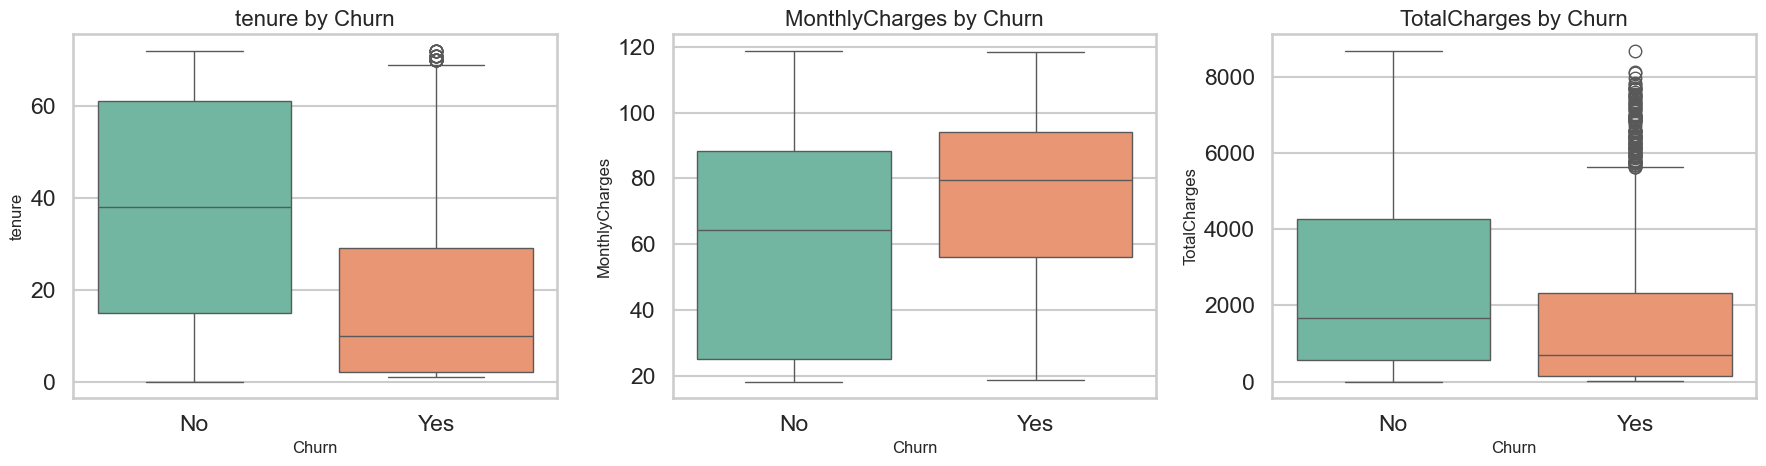

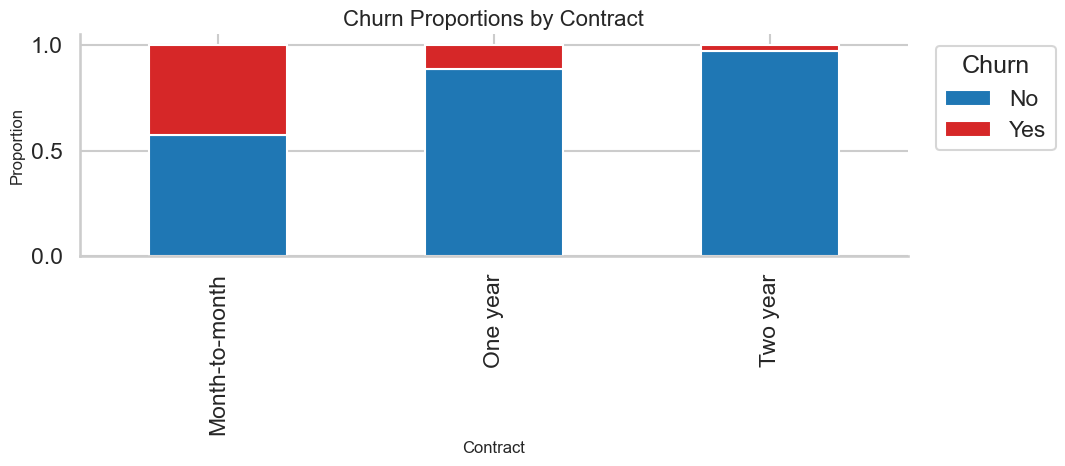

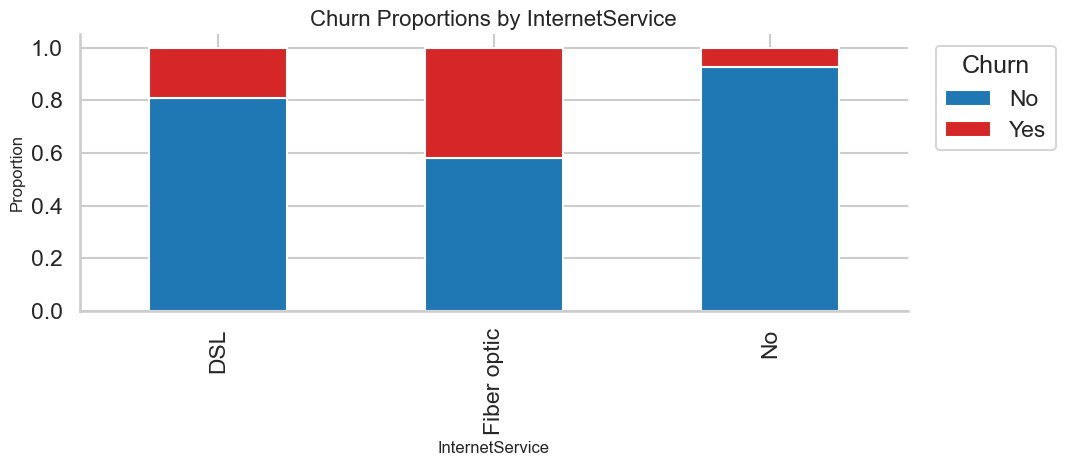

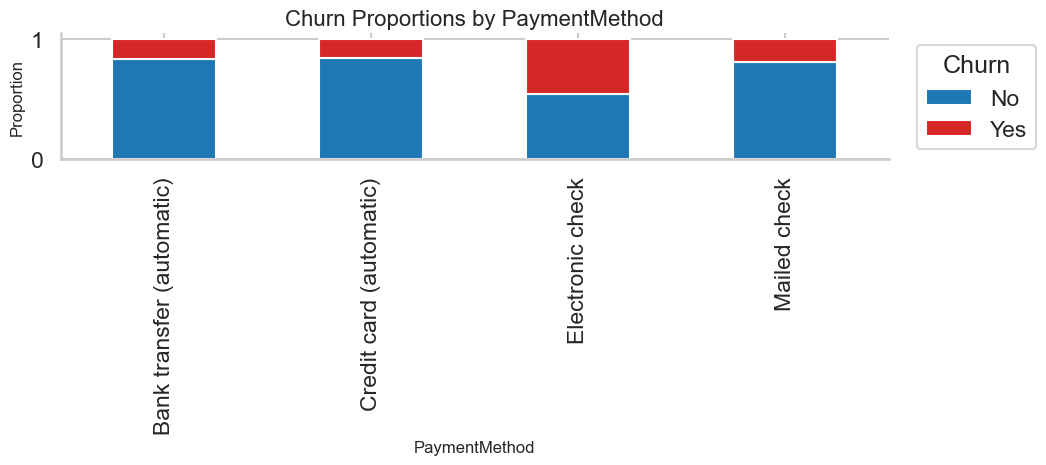

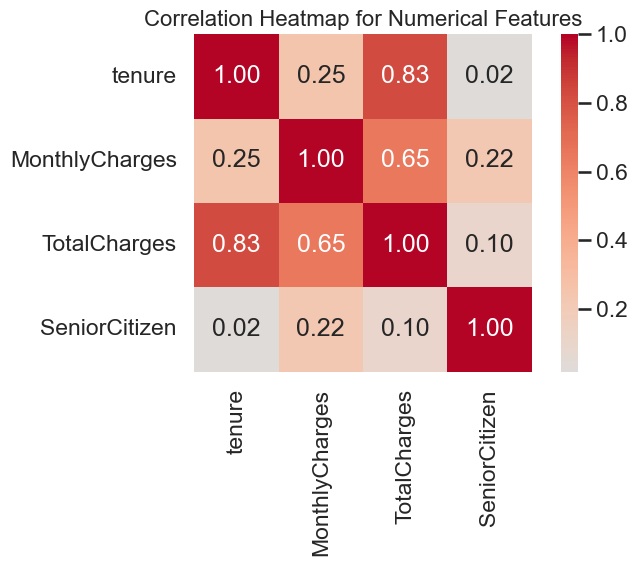

In [4]:
def iqr_outlier_summary(frame: pd.DataFrame, column: str) -> dict:
    q1 = frame[column].quantile(0.25)
    q3 = frame[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (frame[column] < lower) | (frame[column] > upper)
    return {
        'column': column,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': int(mask.sum()),
        'outlier_pct': float(mask.mean() * 100),
    }

outlier_summary = pd.DataFrame([
    iqr_outlier_summary(df_clean, 'MonthlyCharges'),
    iqr_outlier_summary(df_clean, 'TotalCharges'),
])
display(outlier_summary)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5), sharex=False)
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df_clean, x='Churn', y=col, ax=ax, hue='Churn', palette='Set2', dodge=False, legend=False)
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

for feature in ['Contract', 'InternetService', 'PaymentMethod']:
    churn_mix = pd.crosstab(df_clean[feature], df_clean['Churn'], normalize='index')
    churn_mix = churn_mix.reindex(columns=['No', 'Yes'])
    ax = churn_mix.plot(kind='bar', stacked=True, color=['#1f77b4', '#d62728'], figsize=(11, 5))
    ax.set_title(f'Churn Proportions by {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Proportion')
    ax.legend(title='Churn', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
correlation_matrix = df_clean[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, ax=ax)
ax.set_title('Correlation Heatmap for Numerical Features')
plt.tight_layout()
plt.show()

## Section 4: The Reproducible Preprocessing Pipeline

We split the data first, then encode, scale, and pass features through a single scikit-learn pipeline that can be reused in production.

Train shape before preprocessing: (5634, 19)
Test shape before preprocessing: (1409, 19)
Train shape after preprocessing: (5634, 41)
Test shape after preprocessing: (1409, 41)


,tenure,MonthlyCharges,TotalCharges,Partner,Dependents,PhoneService,PaperlessBilling,gender_Female,gender_Male,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen
3738,0.102371,-0.521976,-0.262257,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3151,-0.711743,0.337478,-0.503635,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4860,-0.793155,-0.809013,-0.749883,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3867,-0.263980,0.284384,-0.172722,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3810,-1.281624,-0.676279,-0.989374,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


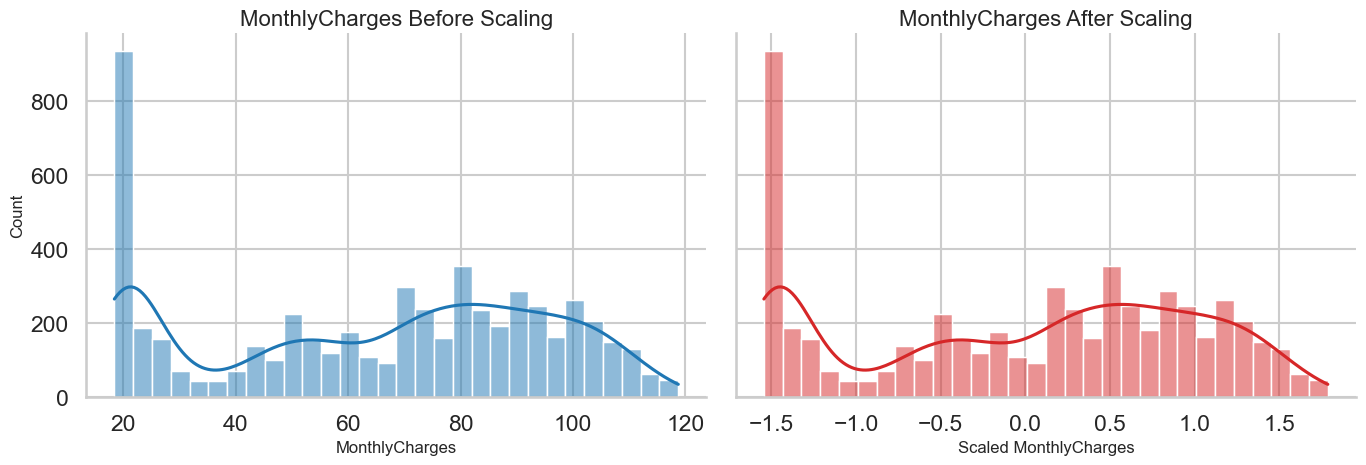

In [5]:
def map_yes_no(values):
    array = np.asarray(values)
    return (array == 'Yes').astype(int)

X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_features = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
nominal_features = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod',
]
pass_through_features = ['SeniorCitizen']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
])

binary_transformer = Pipeline([
    ('to_int', FunctionTransformer(map_yes_no, validate=False, feature_names_out='one-to-one')),
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bin', binary_transformer, binary_features),
        ('cat', categorical_transformer, nominal_features),
        ('pass', 'passthrough', pass_through_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'Train shape before preprocessing: {X_train.shape}')
print(f'Test shape before preprocessing: {X_test.shape}')
print(f'Train shape after preprocessing: {X_train_processed.shape}')
print(f'Test shape after preprocessing: {X_test_processed.shape}')

feature_names = preprocessor.get_feature_names_out()
processed_train_preview = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
display(processed_train_preview.head())

scaled_numeric = preprocessor.named_transformers_['num'].transform(X_train[numeric_features])
scaled_numeric_df = pd.DataFrame(scaled_numeric, columns=numeric_features, index=X_train.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.histplot(X_train['MonthlyCharges'], bins=30, kde=True, color='#1f77b4', ax=axes[0])
axes[0].set_title('MonthlyCharges Before Scaling')
axes[0].set_xlabel('MonthlyCharges')
axes[0].set_ylabel('Count')

sns.histplot(scaled_numeric_df['MonthlyCharges'], bins=30, kde=True, color='#d62728', ax=axes[1])
axes[1].set_title('MonthlyCharges After Scaling')
axes[1].set_xlabel('Scaled MonthlyCharges')
axes[1].set_ylabel('Count')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Next Steps

The notebook now validates the raw table, cleans and inspects missing values, performs churn-focused EDA, and prepares a reusable preprocessing pipeline for downstream modeling or API serving.

## Section 5: Model Experimentation & MLflow Tracking

Train Logistic Regression, Random Forest, XGBoost, and LightGBM; evaluate with Precision/Recall/F1/ROC-AUC; log runs to MLflow and serialize the best pipeline with `joblib`.

In [6]:
# Section 5 imports and MLflow setup
import joblib
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

mlflow.set_experiment('telco_churn_experiments')

def evaluate_model(model, X_valid, y_valid):
    y_pred = model.predict(X_valid)
    # get probability or score for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_valid)[:, 1]
    else:
        # some models expose decision_function
        try:
            y_proba = model.decision_function(X_valid)
        except Exception:
            # fallback to predicted labels if no probabilities available
            y_proba = y_pred
    return {
        'accuracy': accuracy_score(y_valid, y_pred),
        'precision': precision_score(y_valid, y_pred),
        'recall': recall_score(y_valid, y_pred),
        'f1': f1_score(y_valid, y_pred),
        'roc_auc': roc_auc_score(y_valid, y_proba),
    }

models = {
    'logreg': LogisticRegression(max_iter=1000, solver='lbfgs'),
    'rf': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'xgb': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    'lgbm': LGBMClassifier(random_state=42, n_jobs=-1),
}

In [7]:
# Training loop: train each model in a pipeline with the preprocessor, log to MLflow, and keep the best by F1
from sklearn.pipeline import Pipeline

# Ensure no active MLflow run
try:
    if mlflow.active_run() is not None:
        mlflow.end_run()
except Exception:
    pass

results = {}

for name, estimator in models.items():
    with mlflow.start_run(run_name=name):
        pipe = Pipeline([('preprocessor', preprocessor), ('estimator', estimator)])
        pipe.fit(X_train, y_train)
        metrics = evaluate_model(pipe, X_test, y_test)
        try:
            params = estimator.get_params()
        except Exception:
            params = {}
        mlflow.log_params({k: str(v) for k, v in params.items()})
        mlflow.log_metrics(metrics)
        # Log model using `name` only (avoid deprecated artifact_path)
        mlflow.sklearn.log_model(pipe, name=name)
        results[name] = {'pipeline': pipe, 'metrics': metrics}
        print(f"Finished {name} — metrics: {metrics}")

# Select best model by F1 score
best_name = max(results.items(), key=lambda kv: kv[1]['metrics']['f1'])[0]
best_pipeline = results[best_name]['pipeline']
print(f'Best model by F1: {best_name} — {results[best_name]["metrics"]}')

# Serialize best pipeline to disk and log as artifact
joblib.dump(best_pipeline, 'best_pipeline.joblib')
mlflow.log_artifact('best_pipeline.joblib')
print('Saved best_pipeline.joblib and logged to MLflow.')

# Display summary table
summary = pd.DataFrame({
    name: res['metrics'] for name, res in results.items()
}).T
summary = summary.sort_values('f1', ascending=False)
display(summary)

2026/04/30 17:09:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Finished logreg — metrics: {'accuracy': 0.8062455642299503, 'precision': 0.658307210031348, 'recall': 0.5614973262032086, 'f1': 0.6060606060606061, 'roc_auc': 0.8419489007724302}


2026/04/30 17:09:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Finished rf — metrics: {'accuracy': 0.7821149751596878, 'precision': 0.6105610561056105, 'recall': 0.4946524064171123, 'f1': 0.5465288035450517, 'roc_auc': 0.8234131597302952}


d:\MLOPs project\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [17:09:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/04/30 17:09:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Finished xgb — metrics: {'accuracy': 0.772888573456352, 'precision': 0.5823170731707317, 'recall': 0.5106951871657754, 'f1': 0.5441595441595442, 'roc_auc': 0.8151941408974658}
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001308 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


d:\MLOPs project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\MLOPs project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/04/30 17:10:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Finished lgbm — metrics: {'accuracy': 0.7899219304471257, 'precision': 0.6226415094339622, 'recall': 0.5294117647058824, 'f1': 0.5722543352601156, 'roc_auc': 0.8330388281794932}
Best model by F1: logreg — {'accuracy': 0.8062455642299503, 'precision': 0.658307210031348, 'recall': 0.5614973262032086, 'f1': 0.6060606060606061, 'roc_auc': 0.8419489007724302}
Saved best_pipeline.joblib and logged to MLflow.


,accuracy,precision,recall,f1,roc_auc
logreg,0.806246,0.658307,0.561497,0.606061,0.841949
lgbm,0.789922,0.622642,0.529412,0.572254,0.833039
rf,0.782115,0.610561,0.494652,0.546529,0.823413
xgb,0.772889,0.582317,0.510695,0.544160,0.815194


## Section 6: Fine-tuning Baseline Models

We run a quick RandomizedSearchCV for each baseline (LogReg, RF, XGBoost, LightGBM) with small iteration counts to find better hyperparameters, evaluate with F1/ROC-AUC, log tuned runs to MLflow, and save the best tuned pipeline.

In [8]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

# End any active MLflow run to avoid conflicts
try:
    if mlflow.active_run() is not None:
        mlflow.end_run()
except Exception:
    pass

param_distributions = {
    'logreg': {
        'estimator__C': loguniform(1e-4, 1e2),
        'estimator__class_weight': [None, 'balanced'],
    },
    'rf': {
        'estimator__n_estimators': [100, 200, 400],
        'estimator__max_depth': [None, 6, 12, 20],
        'estimator__min_samples_split': [2, 5, 10],
        'estimator__class_weight': [None, 'balanced'],
    },
    'xgb': {
        'estimator__n_estimators': [100, 200, 400],
        'estimator__max_depth': [3, 6, 10],
        'estimator__learning_rate': [0.01, 0.05, 0.1],
    },
    'lgbm': {
        'estimator__n_estimators': [100, 200, 400],
        'estimator__max_depth': [ -1, 6, 12],
        'estimator__learning_rate': [0.01, 0.05, 0.1],
    },
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search_results = {}

# Use deeper n_iter to search more thoroughly as requested
N_ITER = 50

for name, estimator in models.items():
    print(f'Hyperparameter tuning {name} (n_iter={N_ITER})...')
    pipeline = Pipeline([('preprocessor', preprocessor), ('estimator', estimator)])
    param_dist = param_distributions.get(name, {})
    if not param_dist:
        print(f'No param distributions found for {name}, skipping.')
        continue
    rnd = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=N_ITER,
        scoring='f1',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    rnd.fit(X_train, y_train)
    best = rnd.best_estimator_
    tuned_metrics = evaluate_model(best, X_test, y_test)

    # log tuned run (ensure no active run)
    try:
        if mlflow.active_run() is not None:
            mlflow.end_run()
    except Exception:
        pass

    with mlflow.start_run(run_name=f'tuned_{name}'):
        mlflow.log_params({k: str(v) for k, v in rnd.best_params_.items()})
        mlflow.log_metrics(tuned_metrics)
        # log model (use name only)
        mlflow.sklearn.log_model(best, name=f'tuned_{name}')

    search_results[name] = {
        'search': rnd,
        'best_estimator': best,
        'metrics': tuned_metrics,
    }
    print(f'Finished tuning {name} — tuned metrics: {tuned_metrics}')

# Compare baseline vs tuned
baseline_metrics = pd.DataFrame({n: r['metrics'] for n, r in results.items()}).T
# Some models may not have been tuned (if param_dist missing) — filter
tuned_metrics_df = pd.DataFrame({n: r['metrics'] for n, r in search_results.items()}).T
comparison = baseline_metrics.join(tuned_metrics_df, lsuffix='_baseline', rsuffix='_tuned')
# Sort safely if column exists
if 'f1_tuned' in comparison.columns:
    comparison = comparison.sort_values('f1_tuned', ascending=False)
else:
    comparison = comparison

display(comparison)

# Save best tuned pipeline overall
if search_results:
    best_tuned_name = max(search_results.items(), key=lambda kv: kv[1]['metrics']['f1'])[0]
    best_tuned_pipeline = search_results[best_tuned_name]['best_estimator']
    joblib.dump(best_tuned_pipeline, 'best_pipeline_tuned.joblib')
    mlflow.log_artifact('best_pipeline_tuned.joblib')
    print(f'Best tuned pipeline: {best_tuned_name} — metrics: {search_results[best_tuned_name]["metrics"]}')

# Update results dict
results_tuned = search_results

Hyperparameter tuning logreg (n_iter=50)...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


2026/04/30 17:10:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Finished tuning logreg — tuned metrics: {'accuracy': 0.7388218594748048, 'precision': 0.5051724137931034, 'recall': 0.7834224598930482, 'f1': 0.6142557651991615, 'roc_auc': 0.8416182283189957}
Hyperparameter tuning rf (n_iter=50)...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


2026/04/30 17:12:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Finished tuning rf — tuned metrics: {'accuracy': 0.7459190915542938, 'precision': 0.513986013986014, 'recall': 0.786096256684492, 'f1': 0.6215644820295984, 'roc_auc': 0.8410808855821643}
Hyperparameter tuning xgb (n_iter=50)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


...

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

d:\MLOPs project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\MLOPs project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/04/30 17:14:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Finished tuning lgbm — tuned metrics: {'accuracy': 0.7955997161107168, 'precision': 0.6472602739726028, 'recall': 0.5053475935828877, 'f1': 0.5675675675675675, 'roc_auc': 0.8450334547521248}


,accuracy_baseline,precision_baseline,recall_baseline,f1_baseline,roc_auc_baseline,accuracy_tuned,precision_tuned,recall_tuned,f1_tuned,roc_auc_tuned
rf,0.782115,0.610561,0.494652,0.546529,0.823413,0.745919,0.513986,0.786096,0.621564,0.841081
logreg,0.806246,0.658307,0.561497,0.606061,0.841949,0.738822,0.505172,0.783422,0.614256,0.841618
xgb,0.772889,0.582317,0.510695,0.544160,0.815194,0.807665,0.675768,0.529412,0.593703,0.844515
lgbm,0.789922,0.622642,0.529412,0.572254,0.833039,0.795600,0.647260,0.505348,0.567568,0.845033


Best tuned pipeline: rf — metrics: {'accuracy': 0.7459190915542938, 'precision': 0.513986013986014, 'recall': 0.786096256684492, 'f1': 0.6215644820295984, 'roc_auc': 0.8410808855821643}


## Section 7: Feature Importance and Deployment Export

Use the tuned Random Forest to explain the strongest predictors and serialize the full preprocessing + model pipeline for FastAPI deployment.

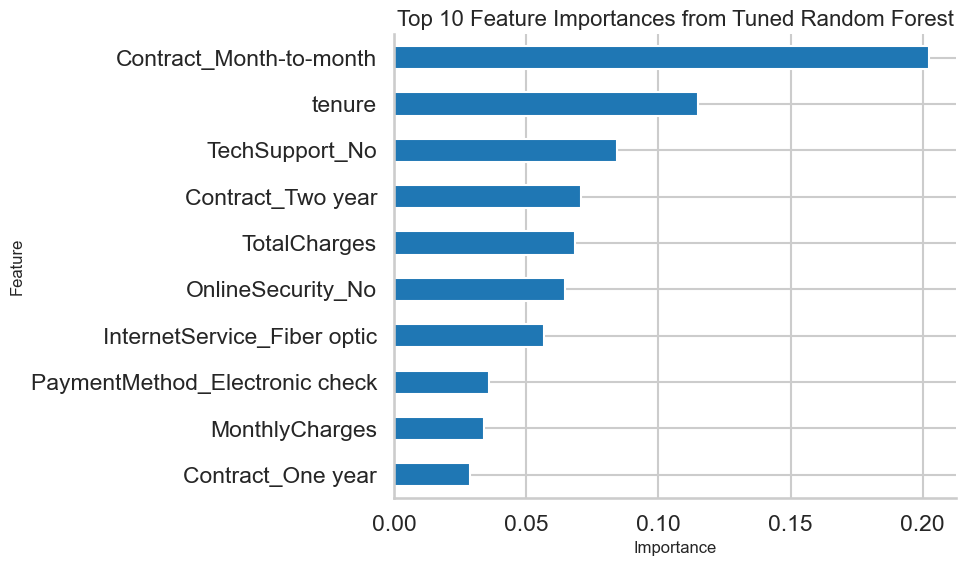

,importance
Contract_Month-to-month,0.202529
tenure,0.115029
TechSupport_No,0.084367
Contract_Two year,0.070650
TotalCharges,0.068270
OnlineSecurity_No,0.064679
InternetService_Fiber optic,0.056678
PaymentMethod_Electronic check,0.036002
MonthlyCharges,0.033905
Contract_One year,0.028542


Saved deployment artifact to churn_inference_pipeline.joblib


In [9]:
import joblib

# Select the tuned Random Forest from the tuning results
if 'results_tuned' in globals() and 'rf' in results_tuned:
    tuned_rf_pipeline = results_tuned['rf']['best_estimator']
elif 'search_results' in globals() and 'rf' in search_results:
    tuned_rf_pipeline = search_results['rf']['best_estimator']
else:
    tuned_rf_pipeline = best_tuned_pipeline

# Extract feature names after preprocessing and align them with RF importances
rf_preprocessor = tuned_rf_pipeline.named_steps['preprocessor']
rf_model = tuned_rf_pipeline.named_steps['estimator']
processed_feature_names = rf_preprocessor.get_feature_names_out()
feature_importances = pd.Series(rf_model.feature_importances_, index=processed_feature_names).sort_values(ascending=False)

top_10_features = feature_importances.head(10).sort_values(ascending=True)

ax = top_10_features.plot(kind='barh', figsize=(10, 6), color='#1f77b4')
ax.set_title('Top 10 Feature Importances from Tuned Random Forest')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

display(feature_importances.head(10).to_frame(name='importance'))

# Serialize the full inference pipeline for FastAPI deployment
joblib.dump(tuned_rf_pipeline, 'churn_inference_pipeline.joblib')
print("Saved deployment artifact to churn_inference_pipeline.joblib")

In [ ]:
from pathlib import Path
import __main__
import joblib
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier


def map_yes_no(values):
    array = np.asarray(values)
    return (array == 'Yes').astype(int)


if not hasattr(__main__, 'map_yes_no'):
    __main__.map_yes_no = map_yes_no

DATA_PATH = Path.cwd() / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Rebuild the modeling table so this section is self-contained.
df_model = pd.read_csv(DATA_PATH)
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce').fillna(0)
df_model = df_model.drop(columns=['customerID'])
df_model['Churn'] = df_model['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_features = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
categorical_features = [column for column in X.columns if column not in numeric_features + binary_features]

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
])

binary_transformer = Pipeline([
    ('to_int', FunctionTransformer(map_yes_no, validate=False, feature_names_out='one-to-one')),
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bin', binary_transformer, binary_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model_candidates = {
    'logreg': LogisticRegression(max_iter=1000, solver='lbfgs'),
    'rf': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'xgb': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    'lgbm': LGBMClassifier(random_state=42, n_jobs=-1),
}


def evaluate_predictions(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba),
    }


baseline_metrics = None
baseline_pipeline_path = Path('best_pipeline.joblib')
if baseline_pipeline_path.exists():
    baseline_pipeline = joblib.load(baseline_pipeline_path)
    baseline_pred = baseline_pipeline.predict(X_test)
    if hasattr(baseline_pipeline, 'predict_proba'):
        baseline_proba = baseline_pipeline.predict_proba(X_test)[:, 1]
    else:
        baseline_proba = baseline_pipeline.predict(X_test)
    baseline_metrics = evaluate_predictions(y_test, baseline_pred, baseline_proba)
    print(f'Baseline best model metrics: {baseline_metrics}')

smote = SMOTE(random_state=42)
smote_results = {}

for name, estimator in model_candidates.items():
    smote_pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('estimator', estimator),
    ])
    smote_pipeline.fit(X_train, y_train)

    y_pred = smote_pipeline.predict(X_test)
    if hasattr(smote_pipeline, 'predict_proba'):
        y_proba = smote_pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = smote_pipeline.predict(X_test)

    metrics = evaluate_predictions(y_test, y_pred, y_proba)
    smote_results[name] = {
        'pipeline': smote_pipeline,
        'metrics': metrics,
    }
    print(f'SMOTE model {name}: {metrics}')

smote_results_df = pd.DataFrame({name: item['metrics'] for name, item in smote_results.items()}).T.sort_values('f1', ascending=False)
display(smote_results_df)

best_smote_name = smote_results_df.index[0]
best_smote_pipeline = smote_results[best_smote_name]['pipeline']
best_smote_metrics = smote_results[best_smote_name]['metrics']
print(f'Best SMOTE model by F1: {best_smote_name} — {best_smote_metrics}')

joblib.dump(best_smote_pipeline, 'best_pipeline_smote.joblib')
print('Saved best_pipeline_smote.joblib')

if baseline_metrics is None or best_smote_metrics['f1'] >= baseline_metrics['f1']:
    joblib.dump(best_smote_pipeline, 'churn_inference_pipeline.joblib')
    print('Updated churn_inference_pipeline.joblib with the best SMOTE model.')
else:
    print('Kept the existing churn_inference_pipeline.joblib because the SMOTE model did not beat the current baseline best.')